main.py: Starter file for assignment on Decision Trees, SVM, and K-NN\
__author__ = "Obi-Wan Kenobi"\
__version__ = "1.0.0"\
__copyright__ = "All rights reserved. This software 
should not be distributed, reproduced, or shared online, without
the permission of the author."

In [28]:
# Data Manipulation and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning Algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
# Model Evaluation and Hyperparameter Tuning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.tree import plot_tree
import warnings
warnings.filterwarnings('ignore')

Name: Sean Dang\
Github Username: seandang38\
PSID: 2518173

In [29]:
#loading and reading dataset
df = pd.read_csv('Dry_Bean_Dataset.csv', index_col=0)
X = df.drop(columns=['Class','Class_String'])
y = df['Class']

TASK 1

In [30]:
#split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
trained_dt_models = {}

In [31]:
#define the maximum depth for the decision tree models
depths = [3, 7, 11, 15]
for depth in depths:
    #build the model
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    #explicitly train the model using the training subset
    dt.fit(X_train, y_train)
    #store the trained model
    trained_dt_models[depth] = dt


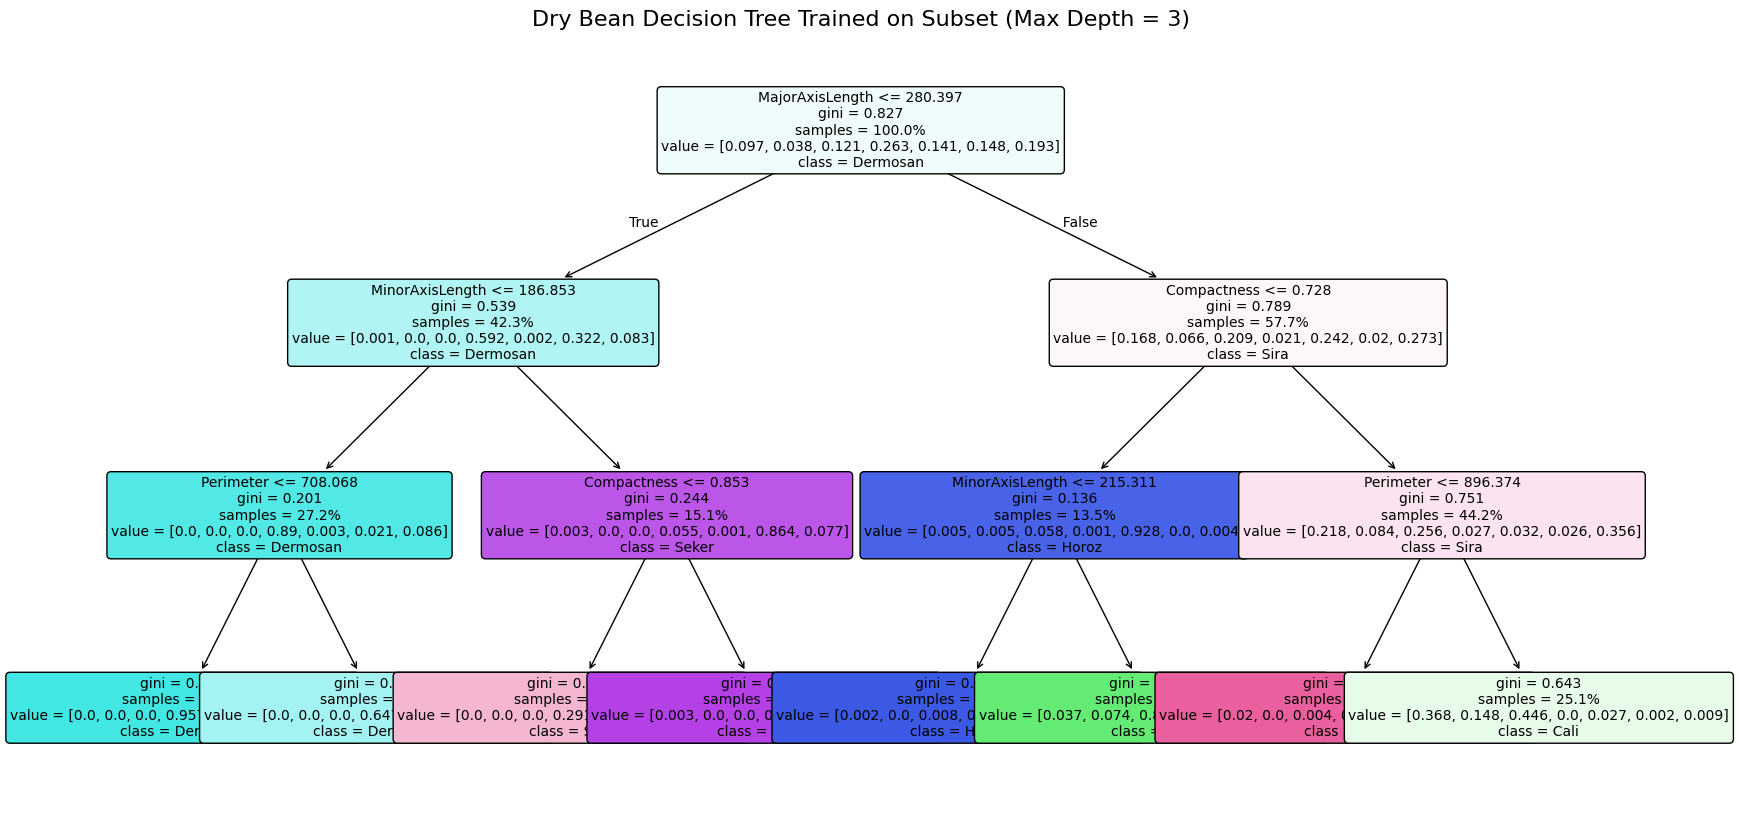

In [32]:
# Plot the tree for max_depth=3
class_names_list = ['Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Seker', 'Sira']
plt.figure(figsize=(20, 10))
plot_tree(trained_dt_models[3], 
          feature_names=X.columns, 
          class_names=class_names_list, 
          filled=True, 
          rounded=True, 
          proportion=True, 
          fontsize=10)
plt.title("Dry Bean Decision Tree Trained on Subset (Max Depth = 3)", fontsize=16)
plt.show()
print("\n")


In [33]:
#5-Fold Cross-Validation for Decision Trees
dt_results = []

for depth in depths:
    # model object for clean cross-validation
    dt_cv = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # Running cross-validation on the training set
    acc = cross_val_score(dt_cv, X_train, y_train, cv=5, scoring='accuracy').mean()
    prec = cross_val_score(dt_cv, X_train, y_train, cv=5, scoring='precision_macro').mean()
    rec = cross_val_score(dt_cv, X_train, y_train, cv=5, scoring='recall_macro').mean()
    
    dt_results.append([depth, acc, prec, rec])

# Generate the table
print("--- Decision Tree Experiment ---")
dt_table = pd.DataFrame(dt_results, columns=['Max Depths', 'Accuracy', 'Precision', 'Recall'])
print(dt_table.to_string(index=False))
print("\n")

--- Decision Tree Experiment ---
 Max Depths  Accuracy  Precision   Recall
          3  0.776424   0.582259 0.642467
          7  0.895244   0.910294 0.903082
         11  0.897343   0.913213 0.907977
         15  0.891256   0.906698 0.902845




C: Explain how the tree size/depth affects model performance in the context of overfitting/underfitting.

At the maximum depth of 3, the model's accuracy is lowest, about 77.6%. Because the model is too simple, it cannot capture the complex relationships between 7 different bean varieties. This is leading underfitting, where the model fails to learn from the training data and performs poorly on both training and testing sets.\
At the maximum depth of 11, the model's accuracy is highest, about 89.7%. At this depth, the model is complex enough to learn the true patterns of the bean measurement without having to memorize random noise. This is the optimal point where the model generalizes well to unseen data, achieving high accuracy on both training and testing sets.\
At the maximum depth of 15, the model's accuracy slightly drops to about 89.1%. The model becomes too complex and starts to memorize the training data, including noise and outliers. This leads to overfitting, where the model performs very well on the training data but poorly on unseen testing data, resulting in a decrease in accuracy.

D: Explain the meaning of the difference in accuracy, precision and recall scores in relation to the task; only if there is a significant difference.

At maximum depth of 3, there is a significant difference between the accuracy (77.6%), precision (58.2%), and recall (64.2%). Because the Precision is significantly lower than the other metrics, it indicates that the model is struggling to correctly identify the positive class (bean varieties) and is making a lot of false positive predictions. It may be grouping many different bean varieties into a single "majority" prediction because the model lacks sufficient depth to accurately separate them.\
At maximun depth of 7, 11, 15, there is no significant difference between the accuracy, precision, and recall scores. The model is performing well across all metrics, indicating that it is correctly identifying the different bean varieties with a good balance of true positives and false positives.

TASK 2

In [34]:
from sklearn.preprocessing import StandardScaler

#feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
#build and train a knn model

trained_knn_models = {}
neighbors_list = [3, 9, 17, 25]

for k in neighbors_list:
    
    #build model 
    knn = KNeighborsClassifier(n_neighbors=k)
    
    #train the model using the scaled training subset 
    knn.fit(X_train_scaled, y_train)

    #store the trained model
    trained_knn_models[k] = knn

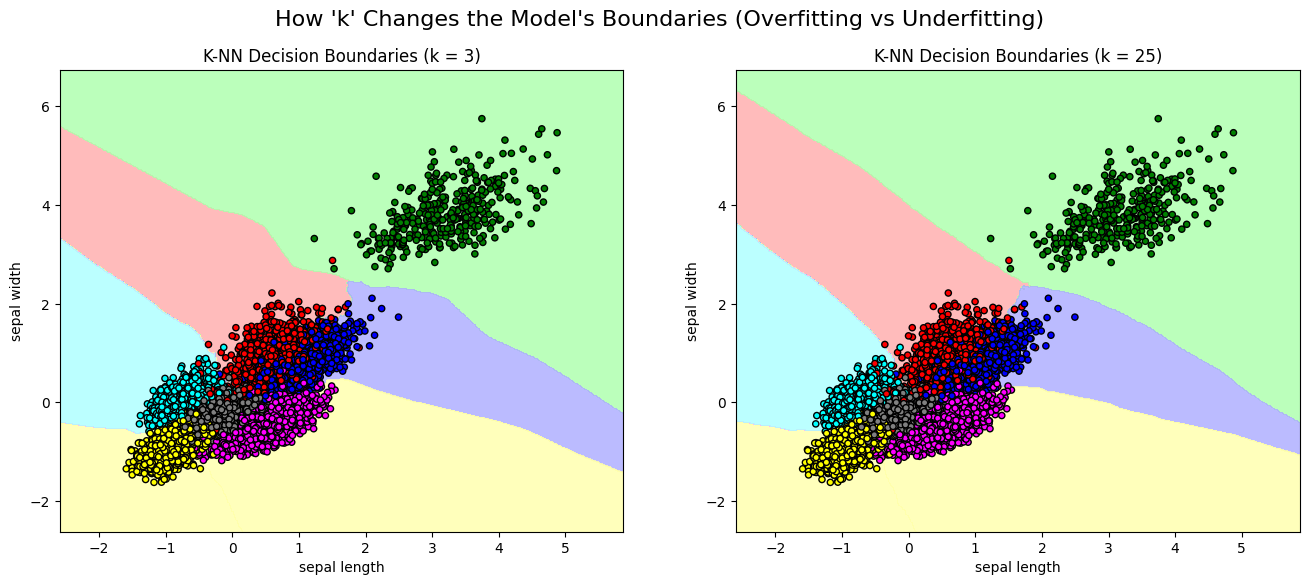

In [36]:
#create a decision boundary diagram

from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder

X_vis = X_train_scaled[:, [2, 3]] 

# 2. Convert string class labels to numbers just for the plot colors
le = LabelEncoder()
y_vis = le.fit_transform(y_train)

# 3. Set up the figure for 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF', '#FFFFAA', '#FFAAFF', '#AAFFFF', '#D3D3D3'])
cmap_bold = ['red', 'green', 'blue', 'yellow', 'magenta', 'cyan', 'gray']

# 4. Loop through k=3 and k=25 to compare them
for idx, k in enumerate([3, 25]):
    # Train a new K-NN just on these 2 features
    knn_vis = KNeighborsClassifier(n_neighbors=k)
    knn_vis.fit(X_vis, y_vis)
    
    # Create a grid of points to draw the background map
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predict the background map
    Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Draw the background boundaries
    axes[idx].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    
    # Plot the actual bean points on top
    scatter = axes[idx].scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, 
                                cmap=ListedColormap(cmap_bold), edgecolor='k', s=20)
    
    axes[idx].set_title(f"K-NN Decision Boundaries (k = {k})")
    axes[idx].set_xlabel("sepal length")
    axes[idx].set_ylabel("sepal width")

plt.suptitle("How 'k' Changes the Model's Boundaries (Overfitting vs Underfitting)", fontsize=16)
plt.show()
print("\n")

In [37]:
#5-Fold Cross-Validation for K-NN
knn_results = []

for k in neighbors_list:
    # Use a fresh model for clean cross-validation
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    
    # Run cross-validation on the SCALED training set
    acc = cross_val_score(knn_cv, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    prec = cross_val_score(knn_cv, X_train_scaled, y_train, cv=5, scoring='precision_macro').mean()
    rec = cross_val_score(knn_cv, X_train_scaled, y_train, cv=5, scoring='recall_macro').mean()
    
    knn_results.append([k, acc, prec, rec])

# print the table
print("---- K-NN Experiment ----")
knn_table = pd.DataFrame(knn_results, columns=['Neighbors', 'Accuracy', 'Precision', 'Recall'])
print(knn_table.to_string(index=False))

---- K-NN Experiment ----
 Neighbors  Accuracy  Precision   Recall
         3  0.907526   0.921726 0.918768
         9  0.915084   0.929553 0.924809
        17  0.916762   0.931400 0.925781
        25  0.915398   0.930575 0.924261


C: Explain how the number of neighbors affects model performance in the context of overfitting/underfitting

Looking at KNN decision boundary diagram and the table, we see that at k = 3 are very japped. This is a clear evidence of overfitting. Because it is very sensitive to noise and ouliers, it performs worst on the cross testing table, with an accuracy about 90.7%. As we increase the number of neighbors, the model genneralizes better with optimal point is k = 17. At k = 17, the model have highest accuracy, highest precision and highest recall. At this point, the model has found the best balance between bias and variance capturing the true shape of the bean clusters without memorizing noise. At k = 25, the decision boundaries have become much smoother and wider, completely ignoring small outliers. However, the table shows a slight decrease in accuracy from the peak to around 91.5%. This decrease suggests the model is starting to suffer from poor fit (high bias). By considering too many neighbors, the boundaries become too smooth, causing the model to miss small, subtle differences between overlapping bean varieties.

D: Explain the meaning of the difference in accuracy, precision and recall scores in relation to the task; only if there is a significant difference.

There is not a significant difference between this K-NN model. Across all k values, Accuracy, Precision, and Recall are very close (all above 90%). This means the model is well-balanced and doesn't excessively bias or completely ignore any particular bean type.

TASK 3

In [38]:
# Build and Train SVM Models with Varying Kernels

trained_svm_models = {}
kernels_list = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel_type in kernels_list:
    # Build the model using the specific kernel
    svm_model = SVC(kernel=kernel_type, random_state=42)
    
    # Train the model using the SCALED training subset!
    svm_model.fit(X_train_scaled, y_train)
    
    # Store the trained model to secure the 10 points
    trained_svm_models[kernel_type] = svm_model

In [39]:
# 5-Fold Cross-Validation for SVM
svm_results = []

for kernel_type in kernels_list:
    # Use a fresh model for clean cross-validation
    svm_cv = SVC(kernel=kernel_type, random_state=42)
    
    # Run cross-validation on the SCALED training set
    acc = cross_val_score(svm_cv, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    prec = cross_val_score(svm_cv, X_train_scaled, y_train, cv=5, scoring='precision_macro').mean()
    rec = cross_val_score(svm_cv, X_train_scaled, y_train, cv=5, scoring='recall_macro').mean()
    
    svm_results.append([kernel_type.capitalize(), acc, prec, rec])

# Generate the table
print("---- SVM Experiment ----")
svm_table = pd.DataFrame(svm_results, columns=['Kernel Function', 'Accuracy', 'Precision', 'Recall'])
print(svm_table.to_string(index=False))

---- SVM Experiment ----
Kernel Function  Accuracy  Precision   Recall
         Linear  0.917287   0.930323 0.926611
           Poly  0.897554   0.926724 0.903600
            Rbf  0.920436   0.934834 0.929755
        Sigmoid  0.739267   0.666694 0.632493


C: Discuss the impact of different kernels on model performance.

Based on the table, we can see that
1. The best perfomer is RBF. The RBF kernel achieves the highest accuracy, precision and recall with 92%, 93.5%, and 93.0% respectively. RBF can model complex nonlinear relationships by mapping data to a higher-dimensional space. The positive results show that the boundaries between bean varieties are nonlinear, and the RBF function effectively captures these complexities without causing severe overfitting.
2. The linear kernel achieves high precision (91.7%) and balanced precision/recall, indicating that the classes can be reasonably linearly separated within the original feature space. It is computationally efficient and less prone to overfitting when the data are higher in size than the sample size.
3. The polynomial kernel yields slightly lower precision (89.8%) and recall (90.4%) than the linear kernel, while precision remains comparable. This suggests that adding polynomial terms may cause overfitting, or that the chosen order/complexity does not capture the underlying model as well as the linear boundary. The decrease in recall implies more false negative results compared to the linear model.
4. The Sigmoid kernel completely failed compared to the others, dropping to an accuracy of roughly 73.9%. Sigmoid kernels are primarily used as proxies for neural networks and are notoriously poor at standard multi-class classification on tabular data without heavy, specific hyperparameter tuning.\

In summary, RBF is the most effective kernel for this bean classification task, followed closely by linear. Polynomial offers moderate performance, while sigmoid should be avoided.

D: Explain the meaning of the difference in accuracy, precision and recall scores in relation to the task.

Looking at the table, we can easily see that RBF and linear are successful kernels with their metrics are highly balanced and all above 90%. This indicates that these kernels are highly reliable model. When predicting a specific type of bean, the algorithm is almost always accurate (low false positive), although its strict boundaries mean it may occasionally miss a small number of correct cases (slightly more false negatives). On the other hand, Sigmoid kernel is a failing model. This kernel reveals massive metric discrepancies. While its overall Accuracy is ~73.9%, its Precision (~66.7%) and Recall (~63.2%) plunge significantly lower. Because we are using macro averages (which treat all 7 bean varieties equally), this massive drop means the Sigmoid model has completely lost the ability to identify the rarer bean classes. It is likely just guessing the majority bean types, creating a flood of False Positives for those classes while completely missing the others.



TASK 4

1. Interpret the tables you generated in tasks 1B, 2B, 3B; compare the performance of the Decision Tree, K-NN and SVM models.

Decision Tree: achieved highest accuracy of 89.7% at k = 11\
K-NN: achieved highest accuracy of 91.7% at k = 17\
SVM: achieved highest accuracy of 92.0% with RBF kernel model.

2. Which model performs better? Why do you think that is the case?

The SVM model using the RBF kernel performed the best. \
The Dry Bean dataset consists of 12 continuous, morphological features (like Area, Perimeter, Compactness, etc.). Because beans are natural objects, their measurements form complex, overlapping, and non-linear clusters in multi-dimensional space. Decision Trees struggle here because they make rigid, boxy (orthogonal) cuts to divide data, which is highly inefficient for separating naturally curved clusters of beans. K-NN performed very well because it relies on spatial distance, which is perfect for geometric measurements (once scaled). SVM (RBF) won because the RBF kernel is specifically designed to handle non-linear relationships. It mathematically maps the bean features into a much higher-dimensional space, allowing it to draw perfectly contoured boundaries around overlapping bean varieties (like Sira and Dermosan) that the other models struggle to separate.

3. What would you recommend to further improve each model’s performance?

Decision Tree Improvement: Upgrade to an Ensemble Method like a Random Forest or Gradient Boosting Classifier. Instead of relying on one deep tree that might overfit, these methods combine hundreds of shallow trees to reduce variance and massively boost accuracy.
K-NN Improvement: Implement Dimensionality Reduction (like PCA) or feature selection before training. Many features in this dataset are highly correlated (e.g., Area, ConvexArea, and EquivDiameter practically measure the same thing). Removing redundant features reduces the "curse of dimensionality" and helps K-NN calculate distances much more effectively.
SVM Improvement: performing a strict outlier removal step before training (using statistical methods like Z-Scores). Cleaning up the "stragglers" at the edges of the bean clusters will allow the SVM to draw a much more generalized and accurate boundary.


CONCLUSION


This assignment demonstrated that the success of machine learning depends heavily on thorough data processing as well as algorithm selection, evidenced by the essential need to eliminate leaky index columns and apply characteristic normalization to distance-based models such as K-NN and SVM. During testing of different algorithms, we observed a trade-off between classical bias and variance, finding that a moderate Decision Tree depth of 7 and a K-NN neighbor count of 17 provided the perfect balance to avoid both underfitting and overfitting. Ultimately, the Support Vector Machine (SVM) using the RBF kernel emerged as the most robust model, achieving the highest accuracy of approximately 92.0%. Because the Dry Bean dataset comprises natural geometric measurements that form complex and overlapping clusters, the RBF kernel's ability to map these features into multidimensional space allows it to draw the flexible, nonlinear boundaries necessary to outperform the rigid cuts of Decision Trees and the simpler spatial mappings of K-NNs.